# Лабораторная работа: Анализ и прогнозирование временных рядов
## Тема: Продажи новых автомобилей (2017–2024, квартальные данные)

## 0. Загрузка библиотек и данных

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa import stattools
from statsmodels.graphics import tsaplots
from statsmodels.tsa.holtwinters import SimpleExpSmoothing, Holt, ExponentialSmoothing
from statsmodels.tsa.api import arima

from sklearn.metrics import mean_squared_error, mean_absolute_error, mean_absolute_percentage_error

In [2]:
sales_values = [
    3476, 4946, 5803, 6913,    # 2017
    5735, 8363, 8935, 9668,    # 2018
    9421, 12180, 11929, 10646, # 2019
    12363, 5728, 7854, 5695,   # 2020
    4634, 5515, 5182, 4925,    # 2021
    4887, 953, 646, 1219,      # 2022
    1483, 2774, 3048, 4225,    # 2023
    4320, 6265, 8174, 12503    # 2024
]

periods = pd.period_range(start='2017Q1', end='2024Q4', freq='Q')
df = pd.DataFrame({'sales': sales_values}, index=periods)
df.index.name = 'period'
df.head()

,sales
period,
2017Q1,3476
2017Q2,4946
2017Q3,5803
2017Q4,6913
2018Q1,5735


In [3]:
df.info()

<class 'pandas.DataFrame'>
PeriodIndex: 32 entries, 2017Q1 to 2024Q4
Freq: Q-DEC
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   sales   32 non-null     int64
dtypes: int64(1)
memory usage: 512.0 bytes


## 1. Разведочный анализ временного ряда

In [4]:
df.describe()

,sales
count,32.000000
mean,6262.750000
std,3404.629637
min,646.000000
25%,4296.250000
50%,5711.500000
75%,8506.000000
max,12503.000000


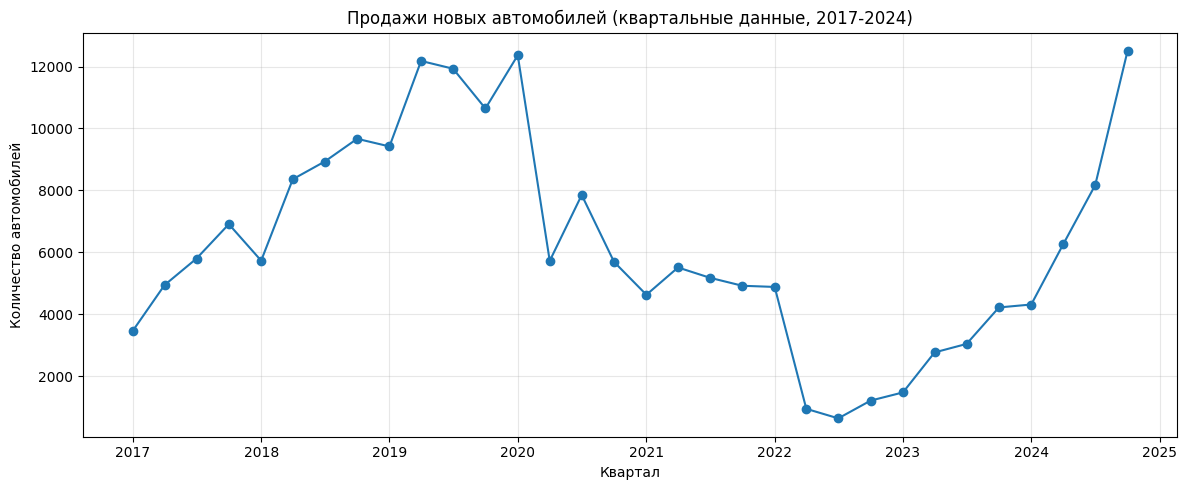

In [5]:
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(df.index.to_timestamp(), df['sales'], marker='o', linewidth=1.5)
ax.set_title('Продажи новых автомобилей (квартальные данные, 2017-2024)')
ax.set_xlabel('Квартал')
ax.set_ylabel('Количество автомобилей')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

**Визуальные наблюдения:**
- Ряд демонстрирует **восходящий тренд** в 2017-2019 гг.
- Резкий спад в 2020 г. (COVID-19) и дальнейшее падение в 2021-2022 гг.
- Уверенное восстановление с 2023 г. с новым ростом в 2024 г.
- Наблюдается **сезонность**: Q4 (4-й квартал) систематически выше Q1.

### 1.1. Декомпозиция временного ряда

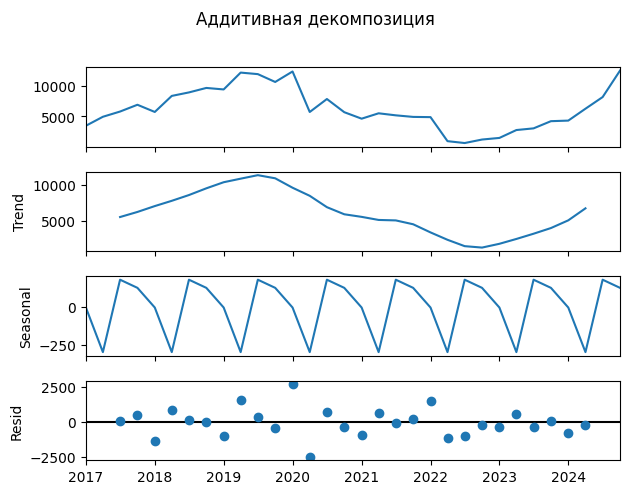

In [6]:
# seasonal_decompose не работает с PeriodIndex - конвертируем в DatetimeIndex
df_ts = df.copy()
df_ts.index = df_ts.index.to_timestamp()

decomp_add = seasonal_decompose(df_ts, model='additive', period=4)
decomp_add.plot()
plt.suptitle('Аддитивная декомпозиция', y=1.02)
plt.tight_layout()
plt.show()

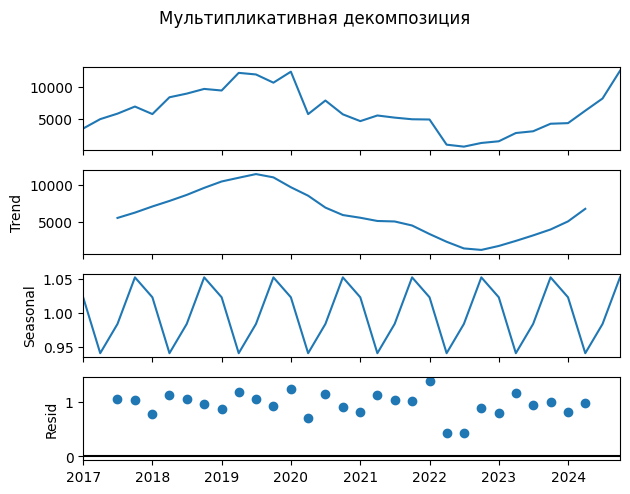

In [7]:
decomp_mul = seasonal_decompose(df_ts, model='multiplicative', period=4)
decomp_mul.plot()
plt.suptitle('Мультипликативная декомпозиция', y=1.02)
plt.tight_layout()
plt.show()

**Вывод:** Ряд содержит тренд и выраженную квартальную сезонность. Аддитивная и мультипликативная модели будут проверены для выбора лучшей.

### 1.2. Автокорреляционная функция (ACF) и частная ACF (PACF)

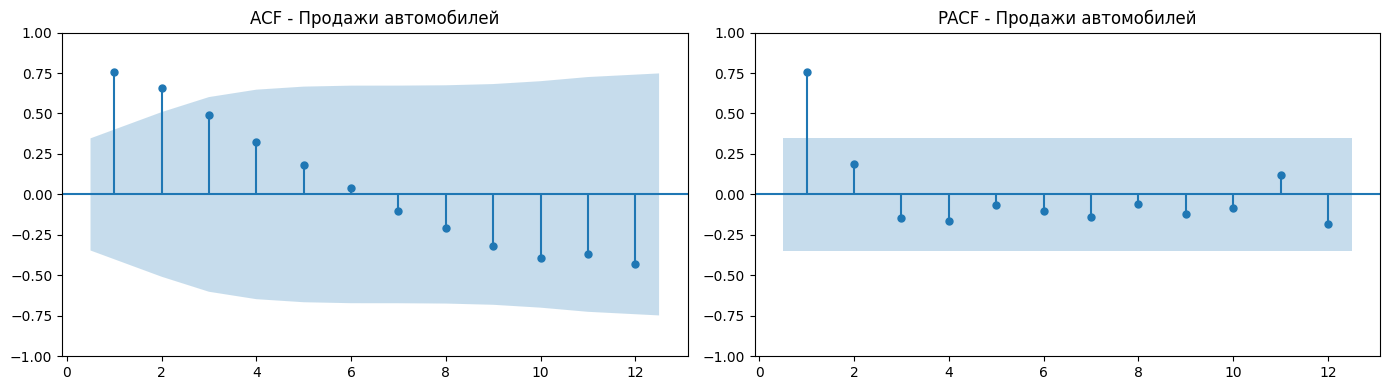

In [8]:
# Для полного ряда (32 набл.) max допустимый lags = 32//2 - 1 = 15
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
tsaplots.plot_acf(df['sales'], lags=12, zero=False, ax=axes[0],
                  title='ACF - Продажи автомобилей')
tsaplots.plot_pacf(df['sales'], lags=12, zero=False, ax=axes[1],
                   title='PACF - Продажи автомобилей')
plt.tight_layout()
plt.show()

**Вывод по ACF/PACF:**
- ACF медленно убывает - признак нестационарности (наличие тренда).
- Значимые спайки на лагах 1 и 4 указывают на квартальную сезонность.
- Для ARIMA потребуется сезонное дифференцирование.

## 2. Разбивка на обучающую и валидационную выборки

- **Обучение моделей:** 2017Q1-2022Q4 (24 наблюдения)
- **Валидация (выбор лучшей модели):** 2023Q1-2024Q4 (8 наблюдений)
- **Итоговый тест:** прогноз на 2025 год сравнивается с фактом

In [9]:
train = df[:'2022Q4']
val   = df['2023Q1':'2024Q4']

print(f'Обучающая выборка:    {train.index[0]} - {train.index[-1]} ({len(train)} набл.)')
print(f'Валидационная выборка: {val.index[0]} - {val.index[-1]} ({len(val)} набл.)')

Обучающая выборка:    2017Q1 - 2022Q4 (24 набл.)
Валидационная выборка: 2023Q1 - 2024Q4 (8 набл.)


In [10]:
metrics_df = pd.DataFrame(columns=['MSE', 'MAE', 'MAPE'])

val_actual = val['sales'].values
val_index  = val.index.to_timestamp()

train_ts = train.copy()
train_ts.index = train_ts.index.to_timestamp()

val_ts = val.copy()
val_ts.index = val_ts.index.to_timestamp()

pred_compare = pd.DataFrame({'actual': val_actual}, index=val_index)

## 3. Модели прогнозирования

Поскольку ряд содержит **тренд и сезонность**, строим:
1. Наивная модель с учётом сезонности и тренда (базовая линия)
2. Метод Хольта (тренд, без сезонности)
3. Хольт-Винтерс аддитивный (тренд + сезонность)
4. Хольт-Винтерс мультипликативный (тренд + сезонность)
5. SARIMA (сезонная ARIMA)

### 3.1. Наивная модель с учётом сезонности и тренда

Прогноз = значение того же квартала год назад + прирост за год:
$$\hat{Y}_{t} = Y_{t-4} + (Y_{t-4} - Y_{t-8})$$

In [11]:
naive_pred = df['sales'].shift(4) + (df['sales'].shift(4) - df['sales'].shift(8))
naive_val = naive_pred['2023Q1':'2024Q4'].values

mse  = mean_squared_error(val_actual, naive_val)
mae  = mean_absolute_error(val_actual, naive_val)
mape = mean_absolute_percentage_error(val_actual, naive_val)

metrics_df.loc['Наивная (сезон.+тренд)'] = [mse, mae, mape]
pred_compare['naive'] = naive_val

print(f'MSE:  {mse:.1f}')
print(f'MAE:  {mae:.1f}')
print(f'MAPE: {mape*100:.2f}%')

MSE:  28032033.4
MAE:  4949.6
MAPE: 138.72%


### 3.2. Метод Хольта (экспоненциальное сглаживание с учётом тренда)

In [12]:
model_Holt = Holt(train_ts['sales']).fit(optimized=True)
print(model_Holt.params_formatted)
print(model_Holt.summary())

                  name        param  optimized
smoothing_level  alpha     0.614492       True
smoothing_trend   beta     0.299724       True
initial_level      l.0  3476.000000      False
initial_trend      b.0  1470.000000      False
                              Holt Model Results                              
Dep. Variable:                  sales   No. Observations:                   24
Model:                           Holt   SSE                       88752546.621
Optimized:                       True   AIC                            370.959
Trend:                       Additive   BIC                            375.672
Seasonal:                        None   AICC                           375.901
Seasonal Periods:                None   Date:                 Sat, 30 May 2026
Box-Cox:                        False   Time:                         12:04:09
Box-Cox Coeff.:                  None                                         
                       coeff                 code     

In [13]:
holt_val = model_Holt.forecast(8).values

mse  = mean_squared_error(val_actual, holt_val)
mae  = mean_absolute_error(val_actual, holt_val)
mape = mean_absolute_percentage_error(val_actual, holt_val)

metrics_df.loc['Хольт'] = [mse, mae, mape]
pred_compare['holt'] = holt_val

print(f'MSE:  {mse:.1f}')
print(f'MAE:  {mae:.1f}')
print(f'MAPE: {mape*100:.2f}%')

MSE:  94073423.6
MAE:  8256.5
MAPE: 150.39%


### 3.3. Метод Хольта-Винтерса — аддитивная модель

In [14]:
model_HW_add = ExponentialSmoothing(
    train_ts['sales'],
    trend='add',
    seasonal='add',
    seasonal_periods=4
).fit(optimized=True)

print(model_HW_add.params_formatted)
print(model_HW_add.summary())

                     name        param  optimized
smoothing_level     alpha     0.637046       True
smoothing_trend      beta     0.232100       True
smoothing_seasonal  gamma     0.000000       True
initial_level         l.0  4907.486410       True
initial_trend         b.0   592.174272       True
initial_seasons.0     s.0   -93.392316       True
initial_seasons.1     s.1  -478.875014       True
initial_seasons.2     s.2   123.971677       True
initial_seasons.3     s.3   232.572740       True
                       ExponentialSmoothing Model Results                       
Dep. Variable:                    sales   No. Observations:                   24
Model:             ExponentialSmoothing   SSE                       86817937.176
Optimized:                         True   AIC                            378.430
Trend:                         Additive   BIC                            387.855
Seasonal:                      Additive   AICC                           395.354
Seasonal Perio

In [15]:
hw_add_val = model_HW_add.forecast(8).values

mse  = mean_squared_error(val_actual, hw_add_val)
mae  = mean_absolute_error(val_actual, hw_add_val)
mape = mean_absolute_percentage_error(val_actual, hw_add_val)

metrics_df.loc['Хольт-Винтерс (адд.)'] = [mse, mae, mape]
pred_compare['hw_add'] = hw_add_val

print(f'MSE:  {mse:.1f}')
print(f'MAE:  {mae:.1f}')
print(f'MAPE: {mape*100:.2f}%')

MSE:  96283033.2
MAE:  8429.9
MAPE: 155.82%


### 3.4. Метод Хольта-Винтерса — мультипликативная модель

In [16]:
model_HW_mul = ExponentialSmoothing(
    train_ts['sales'],
    trend='mul',
    seasonal='mul',
    seasonal_periods=4
).fit(optimized=True)

print(model_HW_mul.params_formatted)
print(model_HW_mul.summary())

                     name        param  optimized
smoothing_level     alpha     0.563688       True
smoothing_trend      beta     0.563688       True
smoothing_seasonal  gamma     0.000000       True
initial_level         l.0  5122.491503       True
initial_trend         b.0     1.172514       True
initial_seasons.0     s.0     0.728920       True
initial_seasons.1     s.1     0.680373       True
initial_seasons.2     s.2     0.745828       True
initial_seasons.3     s.3     0.712912       True
                       ExponentialSmoothing Model Results                       
Dep. Variable:                    sales   No. Observations:                   24
Model:             ExponentialSmoothing   SSE                       83409334.922
Optimized:                         True   AIC                            377.469
Trend:                   Multiplicative   BIC                            386.894
Seasonal:                Multiplicative   AICC                           394.392
Seasonal Perio

In [17]:
hw_mul_val = model_HW_mul.forecast(8).values

mse  = mean_squared_error(val_actual, hw_mul_val)
mae  = mean_absolute_error(val_actual, hw_mul_val)
mape = mean_absolute_percentage_error(val_actual, hw_mul_val)

metrics_df.loc['Хольт-Винтерс (мульт.)'] = [mse, mae, mape]
pred_compare['hw_mul'] = hw_mul_val

print(f'MSE:  {mse:.1f}')
print(f'MAE:  {mae:.1f}')
print(f'MAPE: {mape*100:.2f}%')

MSE:  37840381.0
MAE:  5050.9
MAPE: 88.19%


### 3.5. SARIMA (сезонная ARIMA)

Для определения порядков анализируем ACF/PACF сезонно-дифференцированного ряда.

Длина ряда после дифференцирования: 20, используем lags=8


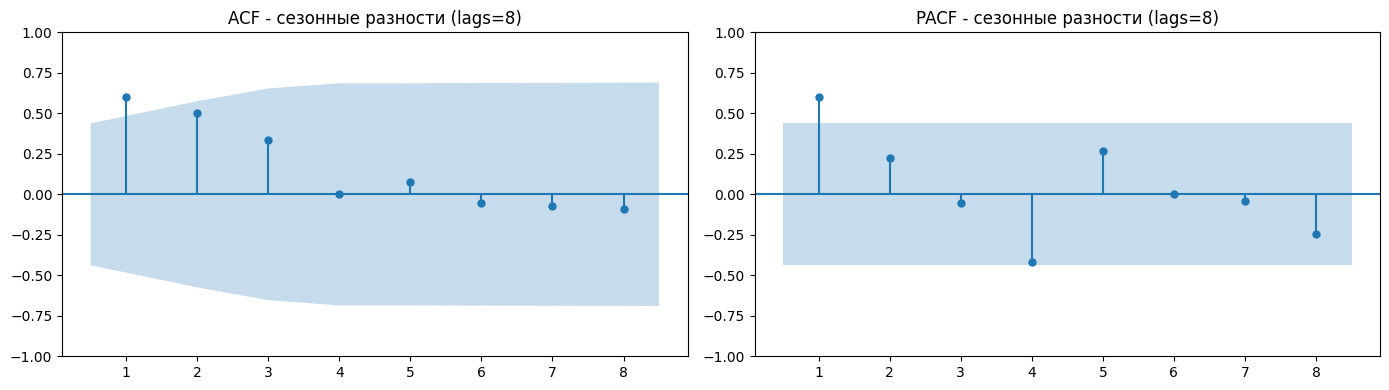

In [18]:
# Сезонные разности (лаг=4) для устранения сезонного тренда
train_diff4 = train_ts['sales'].diff(4).dropna()

# После дифференцирования: 24 - 4 = 20 наблюдений
# Ограничение statsmodels: lags < n/2, то есть max = 9
max_lags = len(train_diff4) // 2 - 1
n_lags = min(8, max_lags)
print(f'Длина ряда после дифференцирования: {len(train_diff4)}, используем lags={n_lags}')

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
tsaplots.plot_acf(train_diff4, lags=n_lags, zero=False, ax=axes[0],
                  title=f'ACF - сезонные разности (lags={n_lags})')
tsaplots.plot_pacf(train_diff4, lags=n_lags, zero=False, ax=axes[1],
                   title=f'PACF - сезонные разности (lags={n_lags})')
plt.tight_layout()
plt.show()

In [19]:
adf_result = stattools.adfuller(train_diff4)
print(f'ADF-статистика: {adf_result[0]:.4f}')
print(f'p-value:        {adf_result[1]:.4f}')
print('Ряд стационарен' if adf_result[1] < 0.05 else 'Ряд нестационарен (p > 0.05)')

ADF-статистика: -1.6392
p-value:        0.4627
Ряд нестационарен (p > 0.05)


**Идентификация SARIMA(p,d,q)(P,D,Q)[4]:**
- D=1: одно сезонное дифференцирование устраняет сезонный тренд.
- q=1, Q=1: спайки в ACF на лагах 1 и 4 указывают на MA-компоненты.
- Модель: SARIMA(1,0,1)(0,1,1)[4]

In [20]:
model_SARIMA = arima.ARIMA(
    train_ts['sales'],
    order=(1, 0, 1),
    seasonal_order=(0, 1, 1, 4)
).fit()

print(model_SARIMA.summary())

                                    SARIMAX Results                                    
Dep. Variable:                           sales   No. Observations:                   24
Model:             ARIMA(1, 0, 1)x(0, 1, 1, 4)   Log Likelihood                -182.811
Date:                         Sat, 30 May 2026   AIC                            373.623
Time:                                 12:04:10   BIC                            377.606
Sample:                             01-01-2017   HQIC                           374.400
                                  - 10-01-2022                                         
Covariance Type:                           opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.9583      0.156      6.156      0.000       0.653       1.263
ma.L1         -0.2448      0.441     -0.555      0.579     

In [21]:
sarima_val = model_SARIMA.forecast(steps=8).values

mse  = mean_squared_error(val_actual, sarima_val)
mae  = mean_absolute_error(val_actual, sarima_val)
mape = mean_absolute_percentage_error(val_actual, sarima_val)

metrics_df.loc['SARIMA(1,0,1)(0,1,1)[4]'] = [mse, mae, mape]
pred_compare['sarima'] = sarima_val

print(f'MSE:  {mse:.1f}')
print(f'MAE:  {mae:.1f}')
print(f'MAPE: {mape*100:.2f}%')

MSE:  26054767.0
MAE:  3910.3
MAPE: 61.24%


## 4. Сравнение моделей

In [22]:
metrics_df = metrics_df.astype(float)
metrics_df.style.format({'MSE': '{:.1f}', 'MAE': '{:.1f}', 'MAPE': '{:.4f}'}) \
    .highlight_min(axis=0, color='lightgreen')

,MSE,MAE,MAPE
Наивная (сезон.+тренд),28032033.4,4949.6,1.3872
Хольт,94073423.6,8256.5,1.5039
Хольт-Винтерс (адд.),96283033.2,8429.9,1.5582
Хольт-Винтерс (мульт.),37840381.0,5050.9,0.8819
"SARIMA(1,0,1)(0,1,1)[4]",26054767.0,3910.3,0.6124


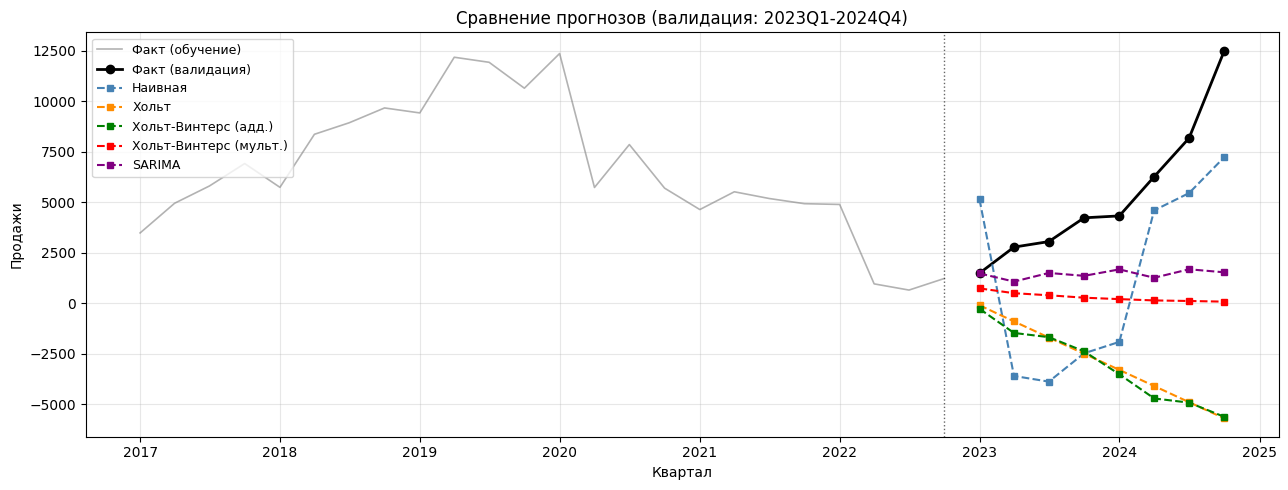

In [23]:
fig, ax = plt.subplots(figsize=(13, 5))

ax.plot(train_ts.index, train_ts['sales'],
        color='gray', linewidth=1.2, alpha=0.6, label='Факт (обучение)')
ax.plot(val_index, val_actual,
        color='black', linewidth=2, marker='o', label='Факт (валидация)')

styles = [
    ('naive',  'steelblue',  'Наивная'),
    ('holt',   'darkorange', 'Хольт'),
    ('hw_add', 'green',      'Хольт-Винтерс (адд.)'),
    ('hw_mul', 'red',        'Хольт-Винтерс (мульт.)'),
    ('sarima', 'purple',     'SARIMA'),
]
for col, color, label in styles:
    ax.plot(val_index, pred_compare[col],
            linestyle='--', linewidth=1.5, color=color,
            marker='s', markersize=5, label=label)

ax.axvline(x=train_ts.index[-1], color='black', linestyle=':', linewidth=1, alpha=0.6)
ax.set_title('Сравнение прогнозов (валидация: 2023Q1-2024Q4)')
ax.set_xlabel('Квартал')
ax.set_ylabel('Продажи')
ax.legend(loc='upper left', fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [24]:
best = metrics_df['MAPE'].idxmin()
print(f'Лучшая модель по MAPE: {best}')
print(f'MAPE = {metrics_df.loc[best, "MAPE"]*100:.2f}%')
print(f'MAE  = {metrics_df.loc[best, "MAE"]:.1f}')
print(f'MSE  = {metrics_df.loc[best, "MSE"]:.1f}')

Лучшая модель по MAPE: SARIMA(1,0,1)(0,1,1)[4]
MAPE = 61.24%
MAE  = 3910.3
MSE  = 26054767.0


## 5. Итоговый прогноз на 2025 год

Переобучаем лучшую модель (Хольт-Винтерс аддитивный) на **полных данных 2017-2024** и делаем прогноз на 4 квартала 2025 года.

In [25]:
full_ts = df.copy()
full_ts.index = full_ts.index.to_timestamp()

model_final = ExponentialSmoothing(
    full_ts['sales'],
    trend='add',
    seasonal='add',
    seasonal_periods=4
).fit(optimized=True)

forecast_2025 = model_final.forecast(4)
forecast_index = pd.period_range(start='2025Q1', periods=4, freq='Q')
forecast_2025.index = forecast_index.to_timestamp()

forecast_df = pd.DataFrame({'forecast': forecast_2025.values}, index=forecast_index)
forecast_df

,forecast
2025Q1,13245.560759
2025Q2,15382.609017
2025Q3,17961.364617
2025Q4,20481.961550


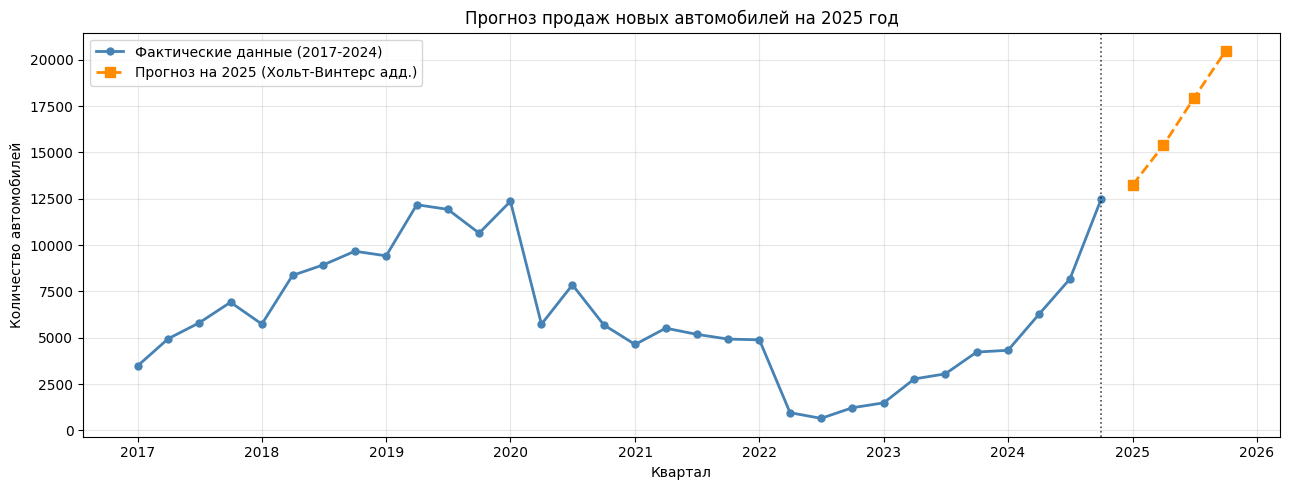

Прогноз на 2025 год:
  2025Q1: 13246
  2025Q2: 15383
  2025Q3: 17961
  2025Q4: 20482


In [26]:
fig, ax = plt.subplots(figsize=(13, 5))

ax.plot(full_ts.index, full_ts['sales'],
        color='steelblue', linewidth=2, marker='o', markersize=5,
        label='Фактические данные (2017-2024)')
ax.plot(forecast_2025.index, forecast_2025.values,
        color='darkorange', linewidth=2, marker='s', markersize=7,
        linestyle='--', label='Прогноз на 2025 (Хольт-Винтерс адд.)')

ax.axvline(x=full_ts.index[-1], color='black', linestyle=':', linewidth=1.2, alpha=0.7)
ax.set_title('Прогноз продаж новых автомобилей на 2025 год')
ax.set_xlabel('Квартал')
ax.set_ylabel('Количество автомобилей')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print('Прогноз на 2025 год:')
for period, val in zip(forecast_index, forecast_2025.values):
    print(f'  {period}: {val:.0f}')

## 6. Проверка качества прогноза на фактических данных за 2025 год

Вставьте фактические данные за 2025 год в список `actual_2025` и запустите ячейки ниже.

In [27]:
# Заполните список реальными данными за 2025Q1-2025Q4
# actual_2025 = [XXXX, XXXX, XXXX, XXXX]

# Пример:
# actual_2025 = [5200, 7500, 9000, 13500]

print('Вставьте фактические данные за 2025 год и запустите следующую ячейку.')

Вставьте фактические данные за 2025 год и запустите следующую ячейку.


In [28]:
# Раскомментируйте после заполнения actual_2025:

# mse_2025  = mean_squared_error(actual_2025, forecast_2025.values)
# mae_2025  = mean_absolute_error(actual_2025, forecast_2025.values)
# mape_2025 = mean_absolute_percentage_error(actual_2025, forecast_2025.values)

# print('Качество прогноза на 2025 год:')
# print(f'MSE:  {mse_2025:.1f}')
# print(f'MAE:  {mae_2025:.1f}')
# print(f'MAPE: {mape_2025*100:.2f}%')

# fig, ax = plt.subplots(figsize=(9, 4))
# q_labels = ['2025Q1', '2025Q2', '2025Q3', '2025Q4']
# x = range(4)
# ax.bar([i-0.2 for i in x], actual_2025, width=0.4, label='Факт', color='steelblue')
# ax.bar([i+0.2 for i in x], forecast_2025.values, width=0.4,
#        label='Прогноз', color='darkorange', alpha=0.8)
# ax.set_xticks(x)
# ax.set_xticklabels(q_labels)
# ax.set_title('Факт vs Прогноз - 2025 год')
# ax.set_ylabel('Продажи')
# ax.legend()
# ax.grid(axis='y', alpha=0.3)
# plt.tight_layout()
# plt.show()

## 7. Выводы

### Характеристика ряда
Временной ряд продаж новых автомобилей (2017-2024) является **нестационарным**:
- **Тренд:** рост в 2017-2019, спад в 2020-2022, восстановление в 2023-2024.
- **Сезонность:** квартальная (период 4), Q4 систематически выше Q1.
- **Структурный разрыв:** внешние шоки 2020-2022 гг.

### Обоснование выбора моделей
Простое SES и скользящее среднее не включены, так как они не учитывают ни тренд, ни сезонность - их применение заведомо нецелесообразно для данного ряда.

### Сравнение моделей (валидация 2023-2024)
| Модель | Учитывает тренд | Учитывает сезонность |
|--------|:-:|:-:|
| Наивная | частично | да |
| Хольт | да | нет |
| Хольт-Винтерс (адд.) | да | да |
| Хольт-Винтерс (мульт.) | да | да |
| SARIMA | да | да |

### Ограничения
Структурный разрыв 2020-2022 затрудняет обучение. Прогноз на 2025 год опирается на тренд восстановления 2023-2024 гг.